In [1]:
root = "DATA" # simlink: ln -s /home/thomas/Desktop/ALLDATA DATA
import glob
import fnmatch
import numpy as np
import matplotlib.pyplot as plt
from plotting import (create_teal_palette, create_blue_violet_palette,
                      create_kiwi_green_palette, create_red_palette, space_axes, lighten_color, stars)
plt.style.use('./Figures/paper.mplstyle')


def initialize_notebook(root=root, ):

    print(f'Found {len(glob.glob(root+"/R*"))} rats in the {root} folder')

    example_rat = 'RatM00'
    example_session = 'RatM00_2021_07_22_16_13_03'

    # Define rat lists
    intact_rats = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02',
                   'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43',
                   'RatM53', 'RatM54', 'Raz41F', 'Raz42F', 'Raz46M', 'Raz47M'
                   ] 
    DSlesioned_rats = ['RatF30', 'RatF31', 'RatM30', 'RatF40', 'RatF41', 'RatM41', 'RatM42',
                       'RatF50', 'RatF51', 'RatF52', 'RatM50', 'RatM51', 'RatM52',
                        # 'Raz52F',
                        # 'Raz53M',
                        'Raz55M'
                       ]
    VSlesioned_rats = [
        'Raz10F', 'Raz11F', 'Raz13F', 'Raz16M',
                       'Raz30F', 'Raz31F','Raz33M', 'Raz34M', 'Raz35M',
                       'Raz40F', 'Raz43M', 'Raz44M', 'Raz45M',
                       'Raz56M', 'Raz57M'
                       ]
    sham_rats = [
        # 'Raz14F', 'Raz19M', 'Raz32F',  'Raz36M'
                 ]
    all_rats = intact_rats + DSlesioned_rats + VSlesioned_rats + sham_rats
    rat_lists = intact_rats, DSlesioned_rats, VSlesioned_rats, sham_rats, all_rats

    male_list = [rat for rat in intact_rats if 'M' in rat]
    female_list = [rat for rat in intact_rats if 'F' in rat]

    print(f'Listed {len(all_rats)} rats in total, of which {len(intact_rats)} are intact ({len(female_list)}♀, {len(male_list)}♂), '
          f'{len(DSlesioned_rats)} DS lesions, {len(VSlesioned_rats)} VS lesions and {len(sham_rats)} shams.')
    print(f'Example rat is {example_rat}, example session: {example_session}')

    # Define marker and color for each rat, used in plots
    rat_markers = {}
    male_palette = create_teal_palette(num_shades=len(male_list))
    female_palette = create_blue_violet_palette(num_shades=len(female_list), start_intensity=80)
    ds_palette = create_kiwi_green_palette(num_shades=len(DSlesioned_rats))
    vs_palette = create_red_palette(num_shades=len(VSlesioned_rats))
    sham_palette = [(.5, .5, .5, .5) for _ in sham_rats]

    for (rat_list, palette) in zip([male_list, female_list, DSlesioned_rats, VSlesioned_rats, sham_rats],
                               [male_palette, female_palette, ds_palette, vs_palette, sham_palette]):
        for (rat, color) in zip(rat_list, palette):
            rat_markers[rat] = [color, 'o', '-']

    GENERAL_PLOT_PARAMS = {'alpha_0':  dict(yticks=[0, 1, 2, 3], yticksdiff=[-0.6, -0.3, 0, 0.3, 0.6], ylabel=r'$\alpha_0$'),
                           'alpha_t':  dict(yticks=[-.1, 0, .1, .2, .3, .4, .5], yticksdiff=[-0.1, -0.05, 0, 0.05, .1], ylabel=r'$\alpha_t$'),
                           'alpha_u':  dict(yticks=[-.4, -.2, 0, .2, .4], yticksdiff=[-0.2, -0.1, 0, 0.1, 0.2], ylabel=r'$\alpha_u$'),
                           'gamma_0':  dict(yticks=[0, 0.5, 1, 1.5, 2], yticksdiff=[-0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3], ylabel=r'$\gamma_0$'),
                           'gamma_t':  dict(yticks=[-.2, -.1, 0, .1], yticksdiff=[-0.04, -.02, 0, 0.02, 0.04], ylabel=r'$\gamma_t$'),
                           'gamma_u':  dict(yticks=[-.6, -.4, -.2, 0, .2], yticksdiff=[-.2, -.1, 0, .1, .2], ylabel=r'$\gamma_u$'),
                           'mu_0':     dict(yticks=[.5, 1, 1.5, 2, 2.5], yticksdiff=[-0.4, -.2, 0, 0.2, 0.4], ylabel=r'$\mu_0$'),
                           'mu_t':     dict(yticks=[0, 0.05, .10, .15, .2], yticksdiff=[-0.04, -0.02, 0, 0.02, 0.04], ylabel=r'$\mu_t$'),
                           'mu_u':     dict(yticks=[-.1, 0, .1, .2],yticksdiff=[-0.04, -0.02, 0, 0.02, 0.04], ylabel=r'$\mu_u$'),
                           'sigma_0':  dict(yticks=[0, .05, .1, .15, .2, .25], yticksdiff=[-0.04, -0.02, 0, 0.02, 0.04], ylabel=r'$\sigma_0$'),
                           'sigma_t':  dict(yticks=[-.06, -.03, 0, .03, .06], yticksdiff=[-0.02, -0.01, 0, 0.01, 0.02], ylabel=r'$\sigma_t$'),
                           'sigma_u':  dict(yticks=[-.03, 0, .03, .06, .09, .12], yticksdiff=[-0.02, -0.01, 0, 0.01, 0.02], ylabel=r'$\sigma_u$'),
                           'effort_sensitivity_0':  dict(yticks=[0, 20, 40, 60], ylabel=r'$\varsigma_0$'),
                           'effort_sensitivity_t':  dict(yticks=[0, 5, 10, 15, 20], ylabel=r'$\varsigma_t$'),
                           'effort_sensitivity_u':  dict(yticks=[-4, -2, 0, 2, 4, 6], ylabel=r'$\varsigma_u$'),
                           'beta':  dict(yticks=[0, 1, 2, 3, 4], ylabel=r'$\beta$'),
                           'total_effort': dict(yticks=[0, 50, 100, 150, 200, 250], ylabel=r'$E_{TOT}$'),
                           'total_drops': dict(yticks=[200, 400, 600, 800], ylabel=r'$R_{TOT}$')}


    return root, rat_lists, rat_markers, (example_rat, example_session), GENERAL_PLOT_PARAMS


In [2]:
import pickle
from matplotlib.patches import Ellipse, Polygon, Circle
import matplotlib.transforms as transforms
from sklearn.metrics import accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression


root, rat_lists, rat_markers, (example_rat, example_session), GENERAL_PLOT_PARAMS = initialize_notebook()
intact_rats, DSlesioned_rats, VSlesioned_rats, sham_rats, all_rats = rat_lists
alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("fitsallrats.p", "rb"))
e0, et, eu, beta = pickle.load(open('effort.p', 'rb'))
parameters = [alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u,
              #   mu_0, mu_t, mu_u, 
              e0, et, eu, beta,
              sigma_0, sigma_t, sigma_u
              ]

X = np.zeros((len(all_rats), len(parameters)))

def avg_param(rat, param):
    conds = ["60", "90", "120", "20", "10", "2", "rev10", "rev20"]
    conds = ["60", "90", "120", "20", "10", "2", "rev10", "rev20"]
    if isinstance(param[rat], dict):
        avg = np.median([param[rat][cond] for cond in conds])
        # print(rat, avg, [param[rat][cond] for cond in conds])
    else:
        avg = param[rat]
        # print(rat, avg)
    return avg

for i, rat in enumerate(all_rats):
    for j, param in enumerate(parameters):
        X[i][j] = avg_param(rat, param)

X_base = X.copy()

ZscoredX = (X - X.mean(axis=0)) / X.std(axis=0)
X = ZscoredX

feature_names = ["alpha_0", "alpha_t", "alpha_u", "gamma_0", "gamma_t", "gamma_u",
                #  "mu_0", "mu_t", "mu_u", 
                 "e0", "et", "eu", "beta",
                 "sigma_0", "sigma_t", "sigma_u"
                 ]

pretty_labels = [r'$\alpha_0$', r"$\alpha_t$", r"$\alpha_u$", r'$\gamma_0$', r"$\gamma_t$", r"$\gamma_u$",
                 r'$\varsigma_0$', r"$\varsigma_t$", r"$\varsigma_u$", r'$\beta$',
                 r'$\sigma_0$', r"$\sigma_t$", r'$\sigma_u$']


target_names = ["Intact", "DS lesion", "VS lesion", "Sham"]
target_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

Found 34 rats in the DATA folder
Listed 48 rats in total, of which 19 are intact (8♀, 11♂), 14 DS lesions, 15 VS lesions and 0 shams.
Example rat is RatM00, example session: RatM00_2021_07_22_16_13_03


In [3]:

def confidence_ellipse(x, y, ax=None, n_std=2.0, color='k', fill=True, zorder=0):
    '''This is from https://matplotlib.org/devdocs/gallery/statistics/confidence_ellipse.html'''
    if ax is None:
        fig, ax = plt.subplots(figsize=(2, 2))

    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)

    # contour
    ellipse_contour = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                        linewidth=1, color=color, fill=False, alpha=.8, zorder=0)

    # Calculating the standard deviation of x from
    # the squareroot of the variance and multiplying
    # with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)

    # calculating the standard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)

    transf = transforms.Affine2D() \
                        .rotate_deg(45) \
                        .scale(scale_x, scale_y) \
                        .translate(mean_x, mean_y)

    ellipse_contour.set_transform(transf + ax.transData)

    if fill:
        ellipse_fill = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                               linewidth=1, color=color, fill=True, alpha=0.1, zorder=zorder)
        ellipse_fill.set_transform(transf + ax.transData)
        return ax.add_patch(ellipse_contour), ax.add_patch(ellipse_fill)
    return ax.add_patch(ellipse_contour)



In [4]:
group_map = {**{rat: "Intact" for rat in intact_rats},
             **{rat: "DS" for rat in DSlesioned_rats},
             **{rat: "VS" for rat in VSlesioned_rats}}

labels = np.array([group_map[rat] for rat in all_rats])

lda = LDA(solver="eigen", shrinkage="auto", n_components=2)
X_lda = lda.fit_transform(X, labels)

log_reg = LogisticRegression(multi_class="multinomial", solver="lbfgs")
log_reg.fit(X_lda, labels)

y_pred = log_reg.predict(X_lda)
acc = accuracy_score(y_pred, labels)

# Permutation test
n_perm = 10000
perm_acc = np.zeros(n_perm)
for i in range(n_perm):
    y_perm = np.random.permutation(labels)
    lda_perm = LDA(solver="eigen", shrinkage="auto", n_components=2)
    X_lda_perm = lda_perm.fit_transform(X, y_perm)
    
    log_reg_perm = LogisticRegression(multi_class="multinomial", solver="lbfgs")
    log_reg_perm.fit(X_lda_perm, y_perm)
    y_pred_perm = log_reg_perm.predict(X_lda_perm)
    perm_acc[i] = accuracy_score(y_pred_perm, y_perm)

p_value = np.mean(perm_acc >= acc)
print(f"Accuracy = {acc:.4f}, $p=$ {p_value:.4f}")

Accuracy = 0.8125, $p=$ 0.0000


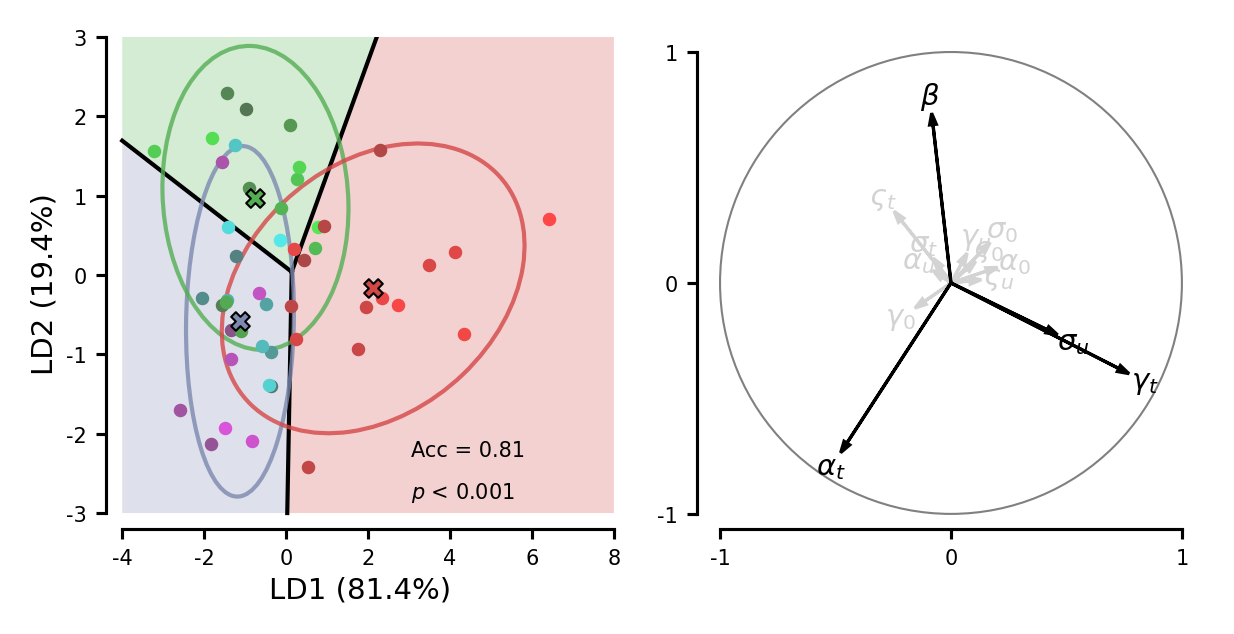

In [5]:
import matplotlib.patches as mpatches
from matplotlib.path import Path

def polygons_from_logreg(log_reg, bbox):
    polygons = []
    lines = []
    for i in range(log_reg.coef_.shape[0]):
        poly = bbox.copy()
        for j in range(log_reg.coef_.shape[0]):
            if i == j:
                continue

            # w[0]*x + w[1]*y + b = 0
            w = log_reg.coef_[i] - log_reg.coef_[j]
            b = log_reg.intercept_[i] - log_reg.intercept_[j]

            new_poly = []
            for k in range(len(poly)):
                P = poly[k]  # current vertex
                Q = poly[(k+1) % len(poly)]  # next one
                fP = w @ P + b  # w[0]*P[0] + w[1]*P[1] + b
                fQ = w @ Q + b  # w[0]*Q[0] + w[1]*Q[1] + b

                if fP >= 0:  # P is on good side
                    new_poly.append(P)
                if fP * fQ < 0:  # edge is outside
                    t = fP / (fP - fQ)
                    I = P + t*(Q-P) # intersection
                    new_poly.append(I)

            poly = np.array(new_poly)
            if len(poly) == 0:
                break
        polygons.append(poly)

    edge_counts = {}
    for poly in polygons:
        for k in range(len(poly)):
            p1 = poly[k]
            p2 = poly[(k+1) % len(poly)]
            p1_rounded = tuple(np.round(p1, 8))
            p2_rounded = tuple(np.round(p2, 8))
            key = tuple(sorted([p1_rounded, p2_rounded]))
            edge_counts[key] = edge_counts.get(key, 0) + 1

    # edges that appear in exactly 2 polygons are boundaries between them
    for key, count in edge_counts.items():
        if count == 2:
            lines.append(key)

    return polygons, lines

def lda_biplot(lda, log_reg, X_lda, p_value=1, accuracy=1, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(2, 2))

    group_colors = {"Intact": np.mean([rat_markers[animal][0] for animal in intact_rats], axis=0),
                    "DS": np.mean([rat_markers[animal][0] for animal in DSlesioned_rats], axis=0),
                    "VS": np.mean([rat_markers[animal][0] for animal in VSlesioned_rats], axis=0)}

    x_intact, y_intact = [], []
    x_ds, y_ds = [], []
    x_vs, y_vs = [], []

    for i, animal in enumerate(all_rats):
        ax.scatter(X_lda[i, 0], X_lda[i, 1], color=rat_markers[animal][0], marker=rat_markers[animal][1], s=5)

        if animal in intact_rats:
            x_intact.append(X_lda[i, 0])
            y_intact.append(X_lda[i, 1])

        if animal in DSlesioned_rats:
            x_ds.append(X_lda[i, 0])
            y_ds.append(X_lda[i, 1])

        if animal in VSlesioned_rats:
            x_vs.append(X_lda[i, 0])
            y_vs.append(X_lda[i, 1])

    # Ellipses
    confidence_ellipse(np.array(x_intact).flatten(), np.array(y_intact).flatten(), color=group_colors["Intact"], ax=ax, fill=False, zorder=10)
    confidence_ellipse(np.array(x_ds).flatten(), np.array(y_ds).flatten(), color=group_colors["DS"], ax=ax, fill=False, zorder=10)
    confidence_ellipse(np.array(x_vs).flatten(), np.array(y_vs).flatten(), color=group_colors["VS"], ax=ax, fill=False, zorder=10)

    # Group means
    group_means = {"Intact": np.array([np.mean(x_intact), np.mean(y_intact)]),
                   "DS": np.array([np.mean(x_ds), np.mean(y_ds)]),
                   "VS": np.array([np.mean(x_vs), np.mean(y_vs)])}
    ax.scatter(*group_means["Intact"], color=group_colors["Intact"], marker='X', s=20, linewidths=.5, edgecolor='k')
    ax.scatter(*group_means["DS"], color=group_colors["DS"], marker='X', s=20, linewidths=.5, edgecolor='k')
    ax.scatter(*group_means["VS"], color=group_colors["VS"], marker='X', s=20, linewidths=.5, edgecolor='k')


    # Decision boundaries
    pad = 2
    x_min, x_max = X_lda[:, 0].min() - pad, X_lda[:, 0].max() + pad
    y_min, y_max = X_lda[:, 1].min() - pad, X_lda[:, 1].max() + pad
    x_min, x_max = -4, 8
    y_min, y_max = -3, 3

    bbox = np.array([[x_min, y_min], [x_max, y_min], [x_max, y_max], [x_min, y_max]])
    polygons, lines = polygons_from_logreg(log_reg, bbox)

    for poly in polygons:
        poly_path = Path(poly)
        for group, mean in group_means.items():
            is_inside = poly_path.contains_point(mean)
            if is_inside:
                patch = Polygon(poly, closed=True, 
                                         facecolor=lighten_color(group_colors[group], factor=0.75), 
                                         edgecolor=None,
                                         zorder=-1)
                ax.add_patch(patch)

    for p1, p2 in lines:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='k', lw=1, zorder=-1)


    ax.set_xlabel(f"LD1 ({lda.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"LD2 ({lda.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_xlim(-4, 8)
    ax.set_xticks([-4, -2, 0, 2, 4, 6, 8])
    ax.set_ylim(-3, 3)
    ax.set_yticks(np.arange(-3, 4, 1))

    ax.annotate(f"Acc = {accuracy:.2f}", xy=(.6, .18), xycoords='axes fraction', fontsize=5, ha='left', va='top')
    ax.annotate(f"{stars(p_value)}", xy=(.6, .1), xycoords='axes fraction', fontsize=5, ha='left', va='top')


    space_axes(ax, x_ratio_right=0)


def inset_lda(lda, labels, ax=None, min_size=0.5, pad=0.075):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(2, 2))

    # Loading arrows
    loadings = lda.scalings_[:, :2]
    for i, var in enumerate(labels):
        vec_len = np.sqrt(loadings[i, 0] ** 2 + loadings[i, 1] ** 2)
        if vec_len > min_size:
            color = 'k'
            zorder = 5
        else:
            color = 'lightgray'
            zorder = 1
        ax.arrow(0, 0, loadings[i, 0], loadings[i, 1], color=color, head_width=0.03, head_length=0.05,
                 linewidth=0.75, length_includes_head=True, zorder=zorder)
        ax.text(loadings[i, 0] + pad * (loadings[i, 0] / vec_len),
                loadings[i, 1] + pad * (loadings[i, 1] / vec_len),
                var, fontsize=7, ha="center", va="center", color=color)

    theta = np.linspace(0, 2*np.pi, 100)
    radius = 1
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    circle = Circle((0, 0), radius, facecolor='white', edgecolor='gray', linewidth=.5, zorder=0)
    ax.add_artist(circle)
    # ax.plot(x, y, color='gray', linewidth=.5, zorder=0)
    ax.plot([-1, 1], [0, 0], color='gray', linestyle='--', linewidth=.5, zorder=0)
    ax.plot([0, 0], [-1, 1], color='gray', linestyle='--', linewidth=.5, zorder=0)

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    space_axes(ax, top_y=.01)
    # ax.axis('off')
    ax.axis('equal')

fig, axs = plt.subplots(1, 2, figsize=(4, 2))
lda_biplot(lda, log_reg, X_lda, p_value=p_value, accuracy=acc, ax=axs[0])
inset_lda(lda, pretty_labels, ax=axs[1])

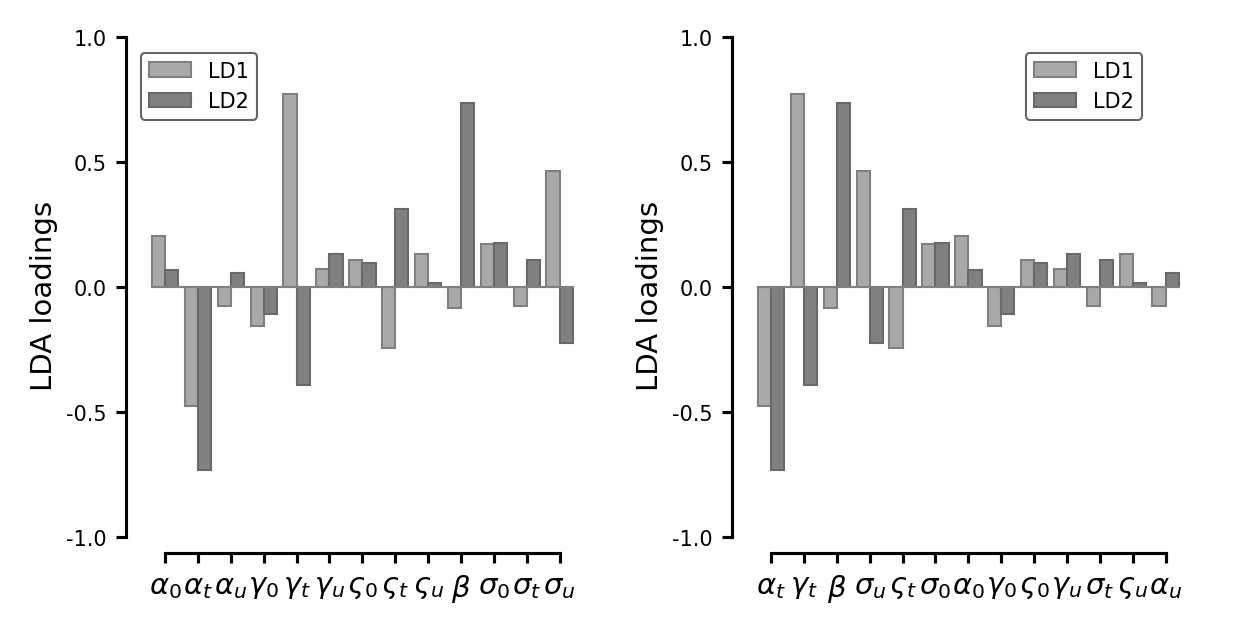

In [6]:
def lda_barplot(lda, labels, ax=None, lw=0.5, w=0.4, sort=False):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(2, 2))

    if sort:
        importance = np.abs(lda.scalings_[:, 0]) + np.abs(lda.scalings_[:, 1])
        order = np.argsort(importance)[::-1]

        labels = [labels[i] for i in order]
        ld1 = lda.scalings_[:, 0][order]
        ld2 = lda.scalings_[:, 1][order]
        bbox = (0.6, 0.99)
    else:
        ld1 = lda.scalings_[:, 0]
        ld2 = lda.scalings_[:, 1]
        bbox = (0.01, 0.99)

    rects1 = ax.bar(np.arange(len(labels)) - w/2, ld1, w, color='gray', facecolor='darkgray', edgecolor='gray', lw=lw, label='LD1')
    rects2 = ax.bar(np.arange(len(labels)) + w/2, ld2, w, color='dimgray', facecolor='gray', edgecolor='dimgray', lw=lw, label='LD2')

    ax.set_xlim(0, len(labels)-1)
    ax.set_ylim(-1, 1)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.set_ylabel('LDA loadings')

    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)

    left, right = -w, len(labels) - 1 + w
    xlim = ax.get_xlim()
    xmin = (left - xlim[0]) / (xlim[1] - xlim[0])
    xmax = (right - xlim[0]) / (xlim[1] - xlim[0])
    ax.axhline(0, color='gray', linestyle='-', linewidth=lw, alpha=1, xmin=xmin, xmax=xmax)
   
    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique), loc='upper left', bbox_to_anchor=bbox, frameon=True, fontsize=5, markerscale=1, edgecolor='k', facecolor='w').get_frame().set_linewidth(.5)
    


fig, axs = plt.subplots(1, 2, figsize=(4, 2))
lda_barplot(lda, pretty_labels, axs[0], sort=False)
lda_barplot(lda, pretty_labels, axs[1], sort=True)

In [7]:
from model_functions import multipletests_bonferroni, exact_mc_perm_test
from plotting import barplot_annotate_brackets

# Load data
effort_sensitivity_0, effort_sensitivity_t, effort_sensitivity_u, power = pickle.load(open('effort.p', 'rb'))
alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("fitsallrats.p", "rb"))

conds = ['60', '90', '120', '20', '10', '2', 'rev10', 'rev20']
median_alpha_0 = {animal: np.median([alpha_0[animal][cond] for cond in conds]) for animal in all_rats}
median_alpha_t = {animal: np.median([alpha_t[animal][cond] for cond in conds]) for animal in all_rats}
median_alpha_u = {animal: np.median([alpha_u[animal][cond] for cond in conds]) for animal in all_rats}
median_gamma_0 = {animal: np.median([gamma_0[animal][cond] for cond in conds]) for animal in all_rats}
median_gamma_t = {animal: np.median([gamma_t[animal][cond] for cond in conds]) for animal in all_rats}
median_gamma_u = {animal: np.median([gamma_u[animal][cond] for cond in conds]) for animal in all_rats}
median_mu_0 = {animal: np.median([mu_0[animal][cond] for cond in conds]) for animal in all_rats}
median_mu_t = {animal: np.median([mu_t[animal][cond] for cond in conds]) for animal in all_rats}
median_mu_u = {animal: np.median([mu_u[animal][cond] for cond in conds]) for animal in all_rats}
median_sigma_0 = {animal: np.median([sigma_0[animal][cond] for cond in conds]) for animal in all_rats}
median_sigma_t = {animal: np.median([sigma_t[animal][cond] for cond in conds]) for animal in all_rats}
median_sigma_u = {animal: np.median([sigma_u[animal][cond] for cond in conds]) for animal in all_rats}

vars = [effort_sensitivity_0, effort_sensitivity_t, effort_sensitivity_u, median_alpha_0, median_alpha_t, median_alpha_u, median_gamma_0, median_gamma_t, median_gamma_u, median_mu_0, median_mu_t, median_mu_u, median_sigma_0, median_sigma_t, median_sigma_u]
names = ['effort_sensitivity_0', 'effort_sensitivity_t', 'effort_sensitivity_u', 'alpha_0', 'alpha_t', 'alpha_u', 'gamma_0', 'gamma_t', 'gamma_u', 'mu_0', 'mu_t', 'mu_u', 'sigma_0', 'sigma_t', 'sigma_u']


In [8]:
print(median_alpha_0)

{'RatF00': 0.8750741365261188, 'RatF01': 1.219839610594236, 'RatF02': 1.4133731170217585, 'RatM00': 2.12024031978641, 'RatM01': 1.7511865182204684, 'RatM02': 1.584685092461225, 'RatF32': 1.3886310098289205, 'RatF33': 0.9918990096751379, 'RatM31': 1.7913963243501003, 'RatM32': 1.2027838139859242, 'RatF42': 1.2771101047928548, 'RatM40': 1.160138499564412, 'RatM43': 1.6104206836390176, 'RatM53': 1.9444293932583276, 'RatM54': 1.7361025676051773, 'Raz41F': 0.8816031609317722, 'Raz42F': 0.8690071113158924, 'Raz46M': 1.6506408616553017, 'Raz47M': 1.3722333536387998, 'RatF30': 2.0440561217309807, 'RatF31': 1.0727034519974157, 'RatM30': 1.7313828412619314, 'RatF40': 1.4136656584334883, 'RatF41': 1.3785742389062023, 'RatM41': 1.4791423628827127, 'RatM42': 1.5304411201192536, 'RatF50': 2.0581669404121308, 'RatF51': 1.621475966173787, 'RatF52': 1.8733631469744787, 'RatM50': 1.1781710313250435, 'RatM51': 2.006891444024176, 'RatM52': 1.7753120156961932, 'Raz55M': 2.6394929784250722, 'Raz10F': 2.1761

In [9]:
COMPARISON_PLOT_PARAMS = {'alpha_0':  dict(variable=median_alpha_0, yticks=[0, 1, 2, 3, 4, 5, 6], ylabel=r'$\alpha_0$'),
                          'alpha_t':  dict(variable=median_alpha_t, yticks=[-.1, 0, .1, .2, .3, .4, .5], ylabel=r'$\alpha_t$'),
                          'alpha_u':  dict(variable=median_alpha_u, yticks=[-1, -.5, 0, .5, 1], ylabel=r'$\alpha_u$'),
                          'gamma_0':  dict(variable=median_gamma_0, yticks=[0, 0.5, 1, 1.5, 2], ylabel=r'$\gamma_0$'),
                          'gamma_t':  dict(variable=median_gamma_t, yticks=[-.2, -.1, 0, .1, .2], ylabel=r'$\gamma_t$'),
                          'gamma_u':  dict(variable=median_gamma_u, yticks=[-.4, -.2, 0, .2], ylabel=r'$\gamma_u$'),
                        #   'mu_0':     dict(variable=median_mu_0, yticks=[.5, 1, 1.5, 2, 2.5], ylabel=r'$\mu_0$'),
                        #   'mu_t':     dict(variable=median_mu_t, yticks=[0, 0.05, .10, .15, .2], ylabel=r'$\mu_t$'),
                        #   'mu_u':     dict(variable=median_mu_u, yticks=[-.1, 0, .1, .2], ylabel=r'$\mu_u$'),
                          'sigma_0':  dict(variable=median_sigma_0, yticks=[0, .1, .2, .3], ylabel=r'$\sigma_0$'),
                          'sigma_t':  dict(variable=median_sigma_t, yticks=[-.03, 0, .03, .06], ylabel=r'$\sigma_t$'),
                          'sigma_u':  dict(variable=median_sigma_u, yticks=[0, .03, .06, .09, .12, .15], ylabel=r'$\sigma_u$'),
                          'effort_sensitivity_0':  dict(variable=effort_sensitivity_0, yticks=[0, 20, 40, 60, 80, 100, 250], ylabel=r'$\varsigma_0$'),
                          'effort_sensitivity_t':  dict(variable=effort_sensitivity_t, yticks=[-5, 0, 5, 10, 15, 20], ylabel=r'$\varsigma_t$'),
                          'effort_sensitivity_u':  dict(variable=effort_sensitivity_u, yticks=[-10, 0, 10, 20, 30], ylabel=r'$\varsigma_u$'),
                          'beta':  dict(variable=beta, yticks=[0, 1, 2, 3, 4, 5], ylabel=r'$\beta$')}


I vs DS: p = 0.006 -> p = 0.017, Sig. with alpha=0.017
I vs VS: p = 0.416 -> p = 1.000, ns. with alpha=0.017
DS vs VS: p = 0.018 -> p = 0.053, ns. with alpha=0.017


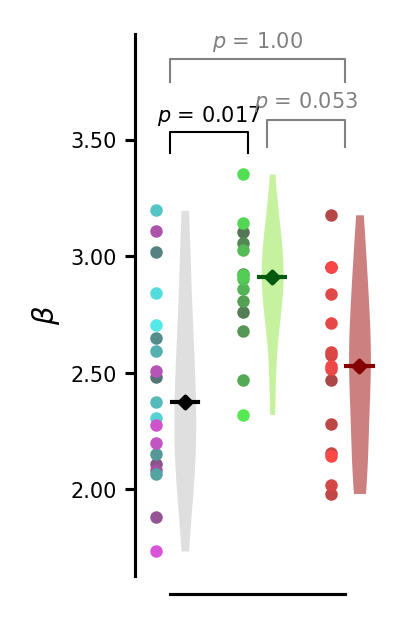

In [ ]:
def Figure(name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(2, 2))

    s = 0.15
    offset = 0.33
    var = COMPARISON_PLOT_PARAMS[name]['variable']

    intact, DSlesion, VSlesion = [], [], []
    for animal in intact_rats:
        intact.append(var[animal])
        ax.scatter(0-offset/2, var[animal], color=rat_markers[animal][0], marker=rat_markers[animal][1], s=4, zorder=5)
    for animal in DSlesioned_rats:
        DSlesion.append(var[animal])
        ax.scatter(1-offset/2, var[animal], color=rat_markers[animal][0], marker=rat_markers[animal][1], s=4, zorder=5)
    for animal in VSlesioned_rats:
        VSlesion.append(var[animal])
        ax.scatter(2-offset/2, var[animal], color=rat_markers[animal][0], marker=rat_markers[animal][1], s=4, zorder=5)


    groupnames = ['I', 'DS', 'VS']
    groups = [intact, DSlesion, VSlesion]
    for i, (group, color, darkcolor) in enumerate(zip(groups,
                                                      ['silver', 'xkcd:kiwi green', 'xkcd:deep red'],
                                                      ['k', 'xkcd:deep green', 'xkcd:dark red'])):
        violin_parts = ax.violinplot(positions=[i+offset/2], dataset=[group], widths=0.25, showextrema=False)
        for vp in violin_parts['bodies']:
            vp.set_facecolor(color)
            vp.set_edgecolor(color)
            vp.set_linewidth(0)
            vp.set_alpha(.5)

        ax.plot([i+offset/2-s, i+offset/2+s], [np.median(group), np.median(group)], color=darkcolor, lw=1, zorder=2)
        ax.scatter(i+offset/2, np.median(group), color=darkcolor, s=4, zorder=3, marker='D')

    # FIXME: 
    # Axes formatting before stats because bpltannotate works with limits. 
    xlabels = groupnames
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(xlabels, fontsize=7)
    ax.set_ylabel(COMPARISON_PLOT_PARAMS[name]['ylabel'])
    # ax.set_ylim(COMPARISON_PLOT_PARAMS[name]['yticks'][0], COMPARISON_PLOT_PARAMS[name]['yticks'][-1])
    # ax.set_yticks(COMPARISON_PLOT_PARAMS[name]['yticks'])
    ax.yaxis.set_major_formatter('{x:<3.2f}')
    ax.set_xlim(0, 2)

    pvalues = []
    pairs = [[0, 1], [0, 2], [1, 2]]
    dhs = [0.05, 0.2, 0.05]  # height offsets for each comparison
    dxs = [[0, -offset/3], [0, 0], [offset/3, 0]]  # x offsets to avoid overlap

    for pair in pairs:
        perm = exact_mc_perm_test(groups[pair[0]], groups[pair[1]])
        pvalues.append(perm)

    max_value = max([max(intact), max(DSlesion), max(VSlesion)])
    sig, corrected_pvalues, alphabonf = multipletests_bonferroni(pvalues, )

    for i, (perm, dh, dx) in enumerate(zip(corrected_pvalues, dhs, dxs)):
        print(f'{groupnames[pairs[i][0]]} vs {groupnames[pairs[i][1]]}: p = {pvalues[i]:<.3f} -> p = {perm:<.3f}, {"Sig." if sig[i] else "ns."} with alpha={alphabonf:.3f}')
        _ = offset / 2
        barplot_annotate_brackets(ax, 0, 1, perm, [pairs[i][0] + dx[0], pairs[i][1] + dx[1]], [max_value, max_value], dh=dh, maxasterix=None, fs=5)

    space_axes(ax, x_ratio_left=.2, x_ratio_right=.2)

fig, axs = plt.subplots(1, 1, figsize=(1.25, 2))
Figure('beta', ax=axs)

alpha_0
I vs DS: p = 0.104 -> p = 0.312, ns. with alpha=0.017
I vs VS: p = 0.004 -> p = 0.013, Sig. with alpha=0.017
DS vs VS: p = 0.257 -> p = 0.770, ns. with alpha=0.017

alpha_t
I vs DS: p = 0.048 -> p = 0.145, ns. with alpha=0.017
I vs VS: p = 0.001 -> p = 0.004, Sig. with alpha=0.017
DS vs VS: p = 0.039 -> p = 0.117, ns. with alpha=0.017

alpha_u
I vs DS: p = 0.702 -> p = 1.000, ns. with alpha=0.017
I vs VS: p = 0.077 -> p = 0.231, ns. with alpha=0.017
DS vs VS: p = 0.238 -> p = 0.715, ns. with alpha=0.017

gamma_0
I vs DS: p = 0.745 -> p = 1.000, ns. with alpha=0.017
I vs VS: p = 1.000 -> p = 1.000, ns. with alpha=0.017
DS vs VS: p = 0.523 -> p = 1.000, ns. with alpha=0.017

gamma_t
I vs DS: p = 0.510 -> p = 1.000, ns. with alpha=0.017
I vs VS: p = 0.000 -> p = 0.000, Sig. with alpha=0.017
DS vs VS: p = 0.001 -> p = 0.004, Sig. with alpha=0.017

gamma_u
I vs DS: p = 0.548 -> p = 1.000, ns. with alpha=0.017
I vs VS: p = 0.329 -> p = 0.988, ns. with alpha=0.017
DS vs VS: p = 0.607 

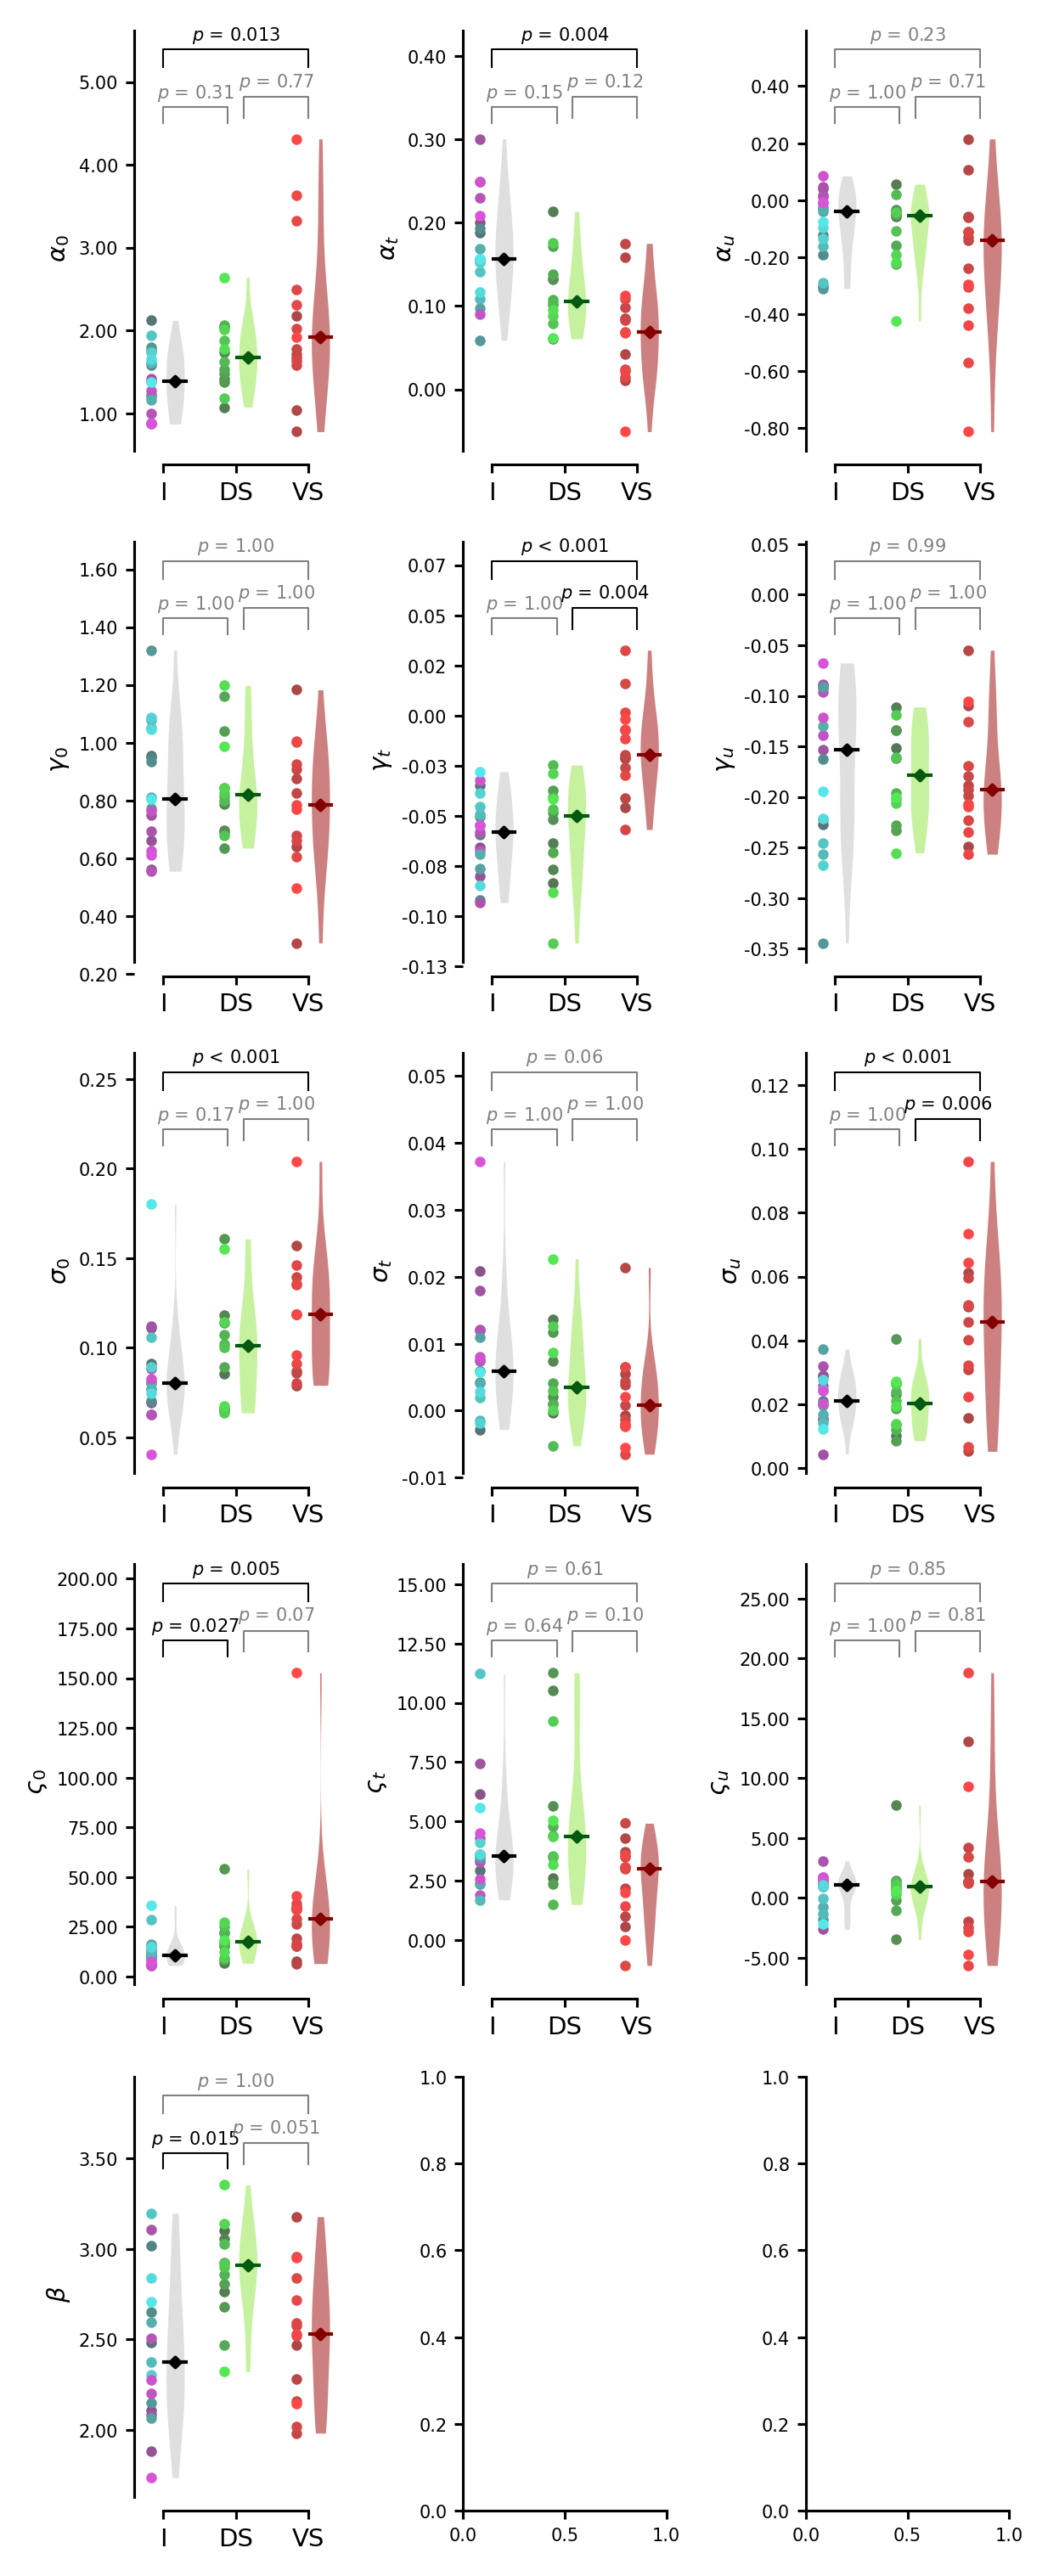

In [12]:
fig, axs = plt.subplots(5, 3, figsize=(4, 10))

for varname, ax in zip(COMPARISON_PLOT_PARAMS.keys(), axs.flatten()):
    print(varname)
    Figure(varname, ax=ax)
    print()

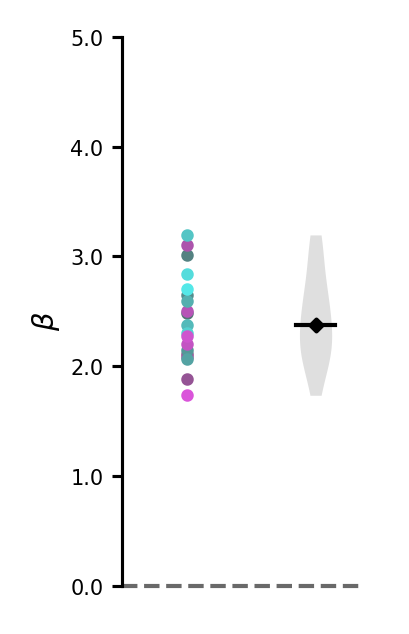

In [79]:
def Figure_(name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(2, 2))

    s = 0.15
    var = COMPARISON_PLOT_PARAMS[name]['variable']

    intact, DSlesion, VSlesion = [], [], []
    for animal in intact_rats:
        intact.append(var[animal])
        ax.scatter(0, var[animal], color=rat_markers[animal][0], marker=rat_markers[animal][1], s=4, zorder=5)

    violin_parts = ax.violinplot(positions=[1], dataset=[intact], widths=0.25, showextrema=False)
    for vp in violin_parts['bodies']:
        vp.set_facecolor('silver')
        vp.set_edgecolor('silver')
        vp.set_linewidth(0)
        vp.set_alpha(.5)

    ax.plot([1-s, 1+s], [np.median(intact), np.median(intact)], color='k', lw=1, zorder=2)
    ax.scatter(1, np.median(intact), color='k', s=4, zorder=3, marker='D')

    ax.set_xticks([0, 1, 2])
    ax.set_ylabel(COMPARISON_PLOT_PARAMS[name]['ylabel'])
    ax.set_ylim(COMPARISON_PLOT_PARAMS[name]['yticks'][0], COMPARISON_PLOT_PARAMS[name]['yticks'][-1])
    ax.set_yticks(COMPARISON_PLOT_PARAMS[name]['yticks'])
    ax.yaxis.set_major_formatter('{x:<3.1f}')
    ax.set_xlim(0, 1)
    ax.xaxis.set_visible(False)
    ax.axes.spines['bottom'].set_visible(False)
    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0, xmax=.92)


    space_axes(ax, x_ratio_left=.5, x_ratio_right=.5)

fig, axs = plt.subplots(1, 1, figsize=(1.25, 2))
Figure_('beta', ax=axs)

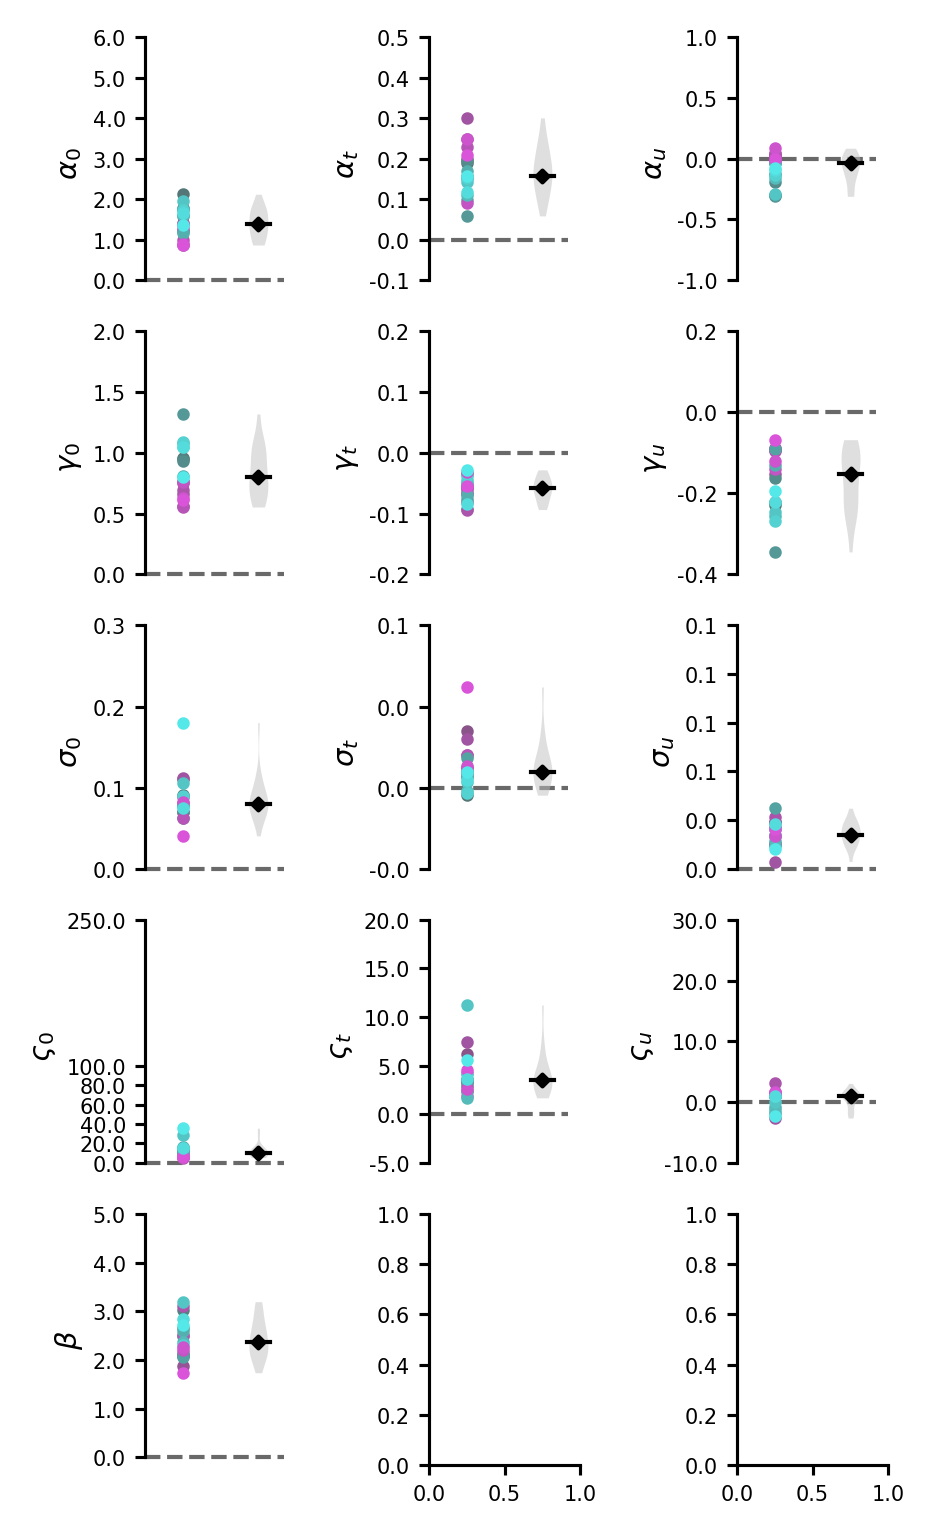

In [80]:
fig, axs = plt.subplots(5, 3, figsize=(3, 5))

for varname, ax in zip(COMPARISON_PLOT_PARAMS.keys(), axs.flatten()):
    Figure_(varname, ax=ax)

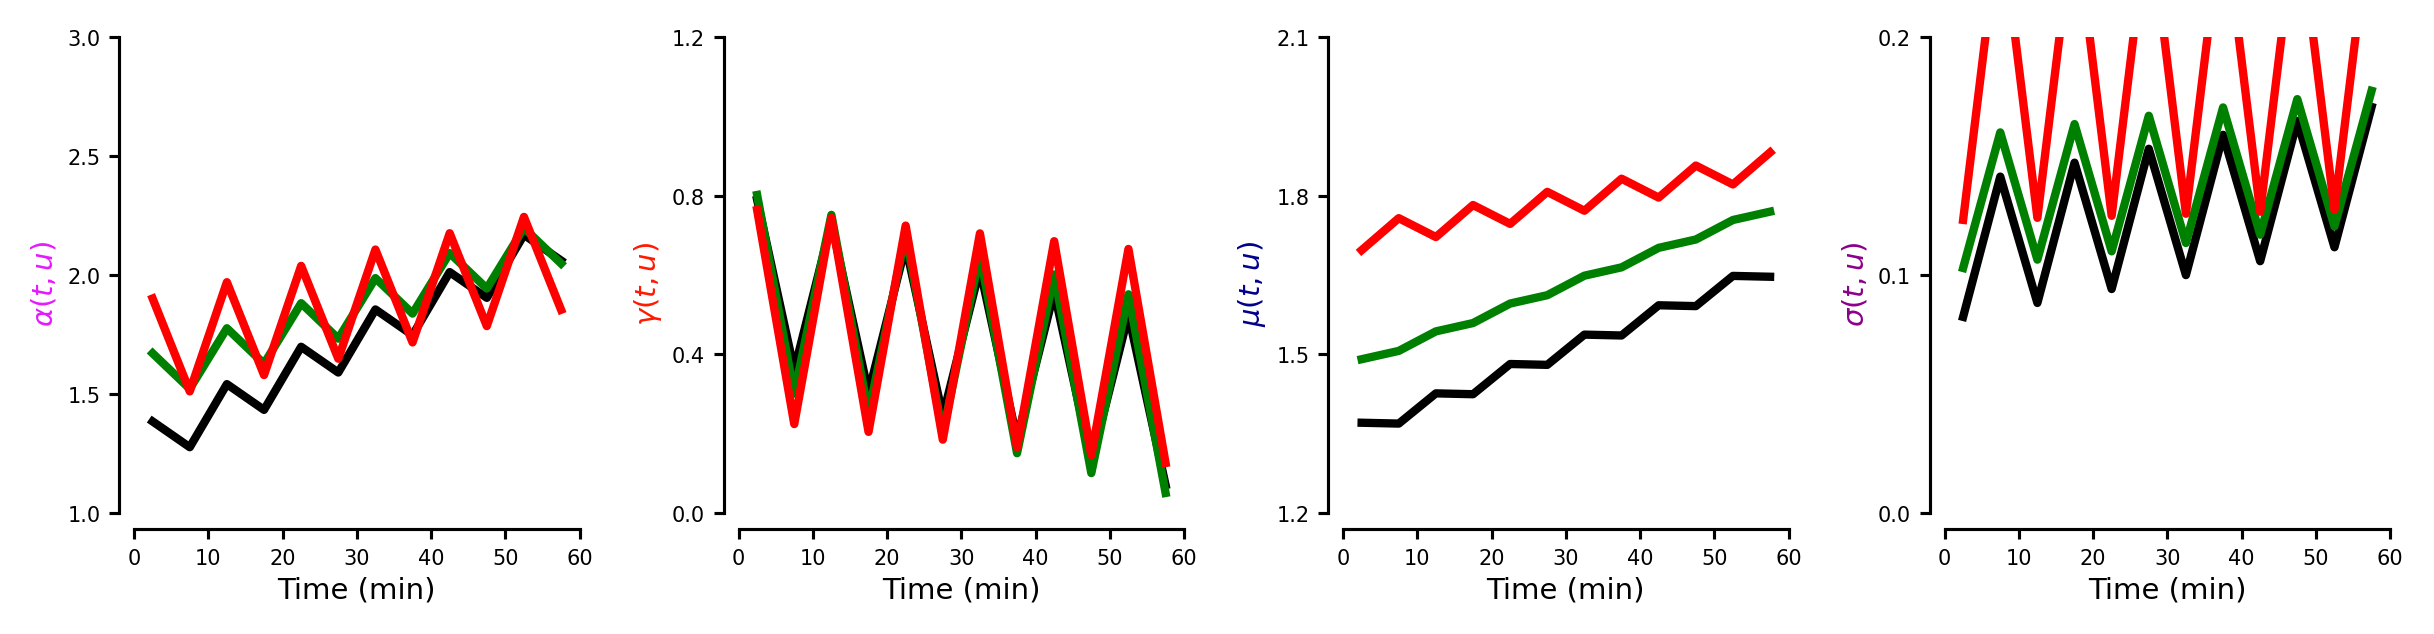

In [81]:
config = {'alpha': {'color': plt.get_cmap('cool_r')(0.1),
                    'varname': r'$\alpha$',
                    'ylims': (1, 3),
                    'yticks': [1, 1.5, 2, 2.5, 3]},
          'gamma': {'color': plt.get_cmap('autumn')(0.1),
                    'varname': r'$\gamma$',
                    'ylims': (0, 1.2),
                    'yticks': [0, 0.4, 0.8, 1.2]},
          'mu': {'color': 'darkblue',
                 'varname': r'$\mu$',
                 'ylims': (1.2, 2.1),
                 'yticks': [1.2, 1.5, 1.8, 2.1]},
          'sigma': {'color': 'darkmagenta',
                    'varname': r'$\sigma$',
                    'ylims': (0, 0.2),
                    'yticks': [0, 0.1, 0.2]}}


def reconstruct_param(alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u):
    N_bins, N_avg = 6, 4
    ALPHA = np.zeros((N_bins, N_avg))
    GAMMA = np.zeros((N_bins, N_avg))
    MU = np.zeros((N_bins, N_avg))
    SIGMA = np.zeros((N_bins, N_avg))

    for bin in range(N_bins):
        for avg in range(N_avg):
            ALPHA[bin, avg] = alpha_0 + bin*alpha_t + avg*alpha_u
            GAMMA[bin, avg] = gamma_0 + bin*gamma_t + avg*gamma_u
            MU[bin, avg] = mu_0 + bin*mu_t + avg*mu_u
            SIGMA[bin, avg] = sigma_0 + bin*sigma_t + avg*sigma_u

    a, g, m, s = [], [], [], []
    for i in range(6):
        a.append(.9*ALPHA[i][0]+0.1*ALPHA[i][1])
        a.append(.9*ALPHA[i][-1]+0.1*ALPHA[i][-2])
        g.append(.9*GAMMA[i][0]+0.1*GAMMA[i][1])
        g.append(.9*GAMMA[i][-1]+0.1*GAMMA[i][-2])
        m.append(.9*MU[i][0]+0.1*MU[i][1])
        m.append(.9*MU[i][-1]+0.1*MU[i][-2])
        s.append(.9*SIGMA[i][0]+0.1*SIGMA[i][1])
        s.append(.9*SIGMA[i][-1]+0.1*SIGMA[i][-2])
    return a, g, m, s

def Figure2D(var_to_plot, animal_lists=[intact_rats, DSlesioned_rats, VSlesioned_rats], group_colors=['k', 'g', 'r'], ax=None):
    if ax is None:
        _, ax = plt.subplots()

    rewardProbaBlock = [90, 10, 90, 10, 90, 10, 90, 10, 90, 10, 90, 10]
    blocks =  [[0, 300],  [300, 600],  [600, 900],  [900, 1200],
                [1200, 1500],  [1500, 1800],  [1800, 2100],  [2100, 2400],
                [2400, 2700],  [2700, 3000],  [3000, 3300],  [3300, 3600]]
    time = [(blocks[i][1] + blocks[i][0]) / 120 for i in range(12)]

    for animal_list, color in zip(animal_lists, group_colors):
        res = np.zeros((len(animal_list), 12))
        for i, animal in enumerate(animal_list):
            a, g, m, s = reconstruct_param(median_alpha_0[animal], median_alpha_t[animal], median_alpha_u[animal],
                                           median_gamma_0[animal], median_gamma_t[animal], median_gamma_u[animal],
                                           median_mu_0[animal], median_mu_t[animal], median_mu_u[animal],
                                           median_sigma_0[animal], median_sigma_t[animal], median_sigma_u[animal])
            param_dict = {'alpha': a, 'gamma': g, 'mu': m, 'sigma': s}
            cfg = config[var_to_plot]
            res[i, :] = param_dict[var_to_plot]
            # ax.plot(time, param_dict[var_to_plot], color=rat_markers[animal][0], linewidth=1, zorder=3)

        group_alpha_0 = np.median([median_alpha_0[animal] for animal in animal_list])
        group_alpha_t = np.median([median_alpha_t[animal] for animal in animal_list])
        group_alpha_u = np.median([median_alpha_u[animal] for animal in animal_list])
        group_gamma_0 = np.median([median_gamma_0[animal] for animal in animal_list])
        group_gamma_t = np.median([median_gamma_t[animal] for animal in animal_list])
        group_gamma_u = np.median([median_gamma_u[animal] for animal in animal_list])
        group_mu_0 = np.median([median_mu_0[animal] for animal in animal_list])
        group_mu_t = np.median([median_mu_t[animal] for animal in animal_list])
        group_mu_u = np.median([median_mu_u[animal] for animal in animal_list])
        group_sigma_0 = np.median([median_sigma_0[animal] for animal in animal_list])
        group_sigma_t = np.median([median_sigma_t[animal] for animal in animal_list])
        group_sigma_u = np.median([median_sigma_u[animal] for animal in animal_list])

        median_a, median_g, median_m, median_s = reconstruct_param(group_alpha_0, group_alpha_t, group_alpha_u,
                                                                group_gamma_0, group_gamma_t, group_gamma_u,
                                                                group_mu_0, group_mu_t, group_mu_u,
                                                                group_sigma_0, group_sigma_t, group_sigma_u)
        group_param_dict = {'alpha': median_a, 'gamma': median_g, 'mu': median_m, 'sigma': median_s}
        ax.plot(time, group_param_dict[var_to_plot], color=color, linewidth=2, zorder=4)

        # median_res = np.median(res, axis=0)
        # ax.plot(time, median_res, color=color, linewidth=1, linestyle='--', zorder=5)

    # plot params and annotations (needs to be before annotations here)
    ax.set_xlabel("Time (min)")
    ax.set_xlim(0, 60)
    ax.set_xticks([0, 10, 20, 30, 40, 50, 60])
    ax.set_ylim(cfg['ylims'])
    yticks_all = sorted(cfg['yticks'])
    ax.set_yticks(yticks_all)

    ax.set_ylabel(cfg['varname'] + '$(t, u)$', color=cfg['color'])







    space_axes(ax)

fig, axs = plt.subplots(1, 4, figsize=(8, 2))
for ax, name in zip(axs, ['alpha', 'gamma', 'mu', 'sigma']):
    Figure2D(var_to_plot=name, ax=ax)


In [93]:
def correct_weights(p, n=3):
    def _fact(x):
        result = 1
        for i in range(1, x+1):
            result *= i
        return result
    def _nCk(n, k):
        return _fact(n) // (_fact(k) * _fact(n-k))

    return [_nCk(n, k) * (p ** k) * ((1 - p) ** (n - k)) for k in range(n + 1)]

probs = correct_weights(0.9, 3)
for n in range(len(probs)):
    print(f"{n}/3: {probs[n]:.3f}")


0/3: 0.001
1/3: 0.027
2/3: 0.243
3/3: 0.729


[0.0009999999999999994, 0.02699999999999999, 0.24299999999999997, 0.7290000000000001]
[0.7290000000000001, 0.24300000000000005, 0.027000000000000007, 0.0010000000000000002]


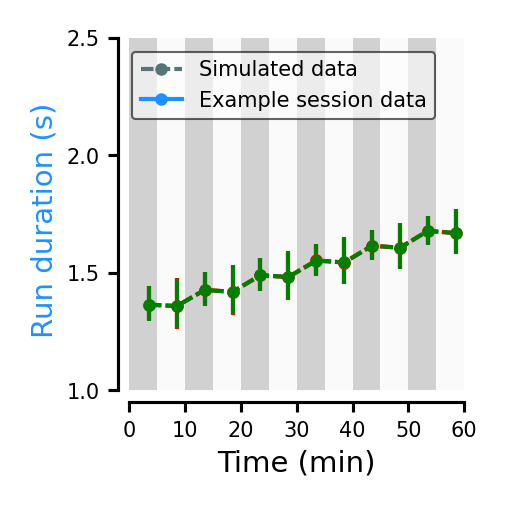

In [105]:
from utils import get_from_pickle, cm2inch
from model_functions import generate_running_time, generate_idle_time
def FigureS6E(root=root, ax=None, show_ylabel=False, animal=example_rat, session=example_session):
    if ax is None:
        ax = plt.gca()

    rewardProbaBlock = [90, 10, 90, 10, 90, 10, 90, 10, 90, 10, 90, 10]
    blocks =  [[0, 300],  [300, 600],  [600, 900],  [900, 1200],
                [1200, 1500],  [1500, 1800],  [1800, 2100],  [2100, 2400],
                [2400, 2700],  [2700, 3000],  [3000, 3300],  [3300, 3600]]
    
    for i in range(0, len(blocks)):
        ax.axvspan(blocks[i][0]/60, blocks[i][1]/60, ymin=1/30, ymax=1, color='grey', alpha=rewardProbaBlock[i]/250, lw=0)
    
    ax.set_xlabel("Time (min)")
    if show_ylabel:
        ax.set_ylabel("Run duration (s)", color='dodgerblue')
    ax.set_xlim(0, 60)
    ax.set_xticks([0, 10, 20, 30, 40, 50, 60])
    ax.set_ylim(1, 2.5)
    ax.set_yticks([1, 1.5, 2, 2.5])
    ax.yaxis.set_major_formatter('{x:<1.1f}')
    space_axes(ax)

    # fit, generate samples from distribution with fit parameters, take median
    N_bins = 6
    N_avg = 4
    ex_mu, ex_mu_t, ex_mu_u, ex_sigma, ex_sigma_t, ex_sigma_u = pickle.load(open("picklejar/example_session_fit_run_duration.p", "rb"))
    MU = np.zeros((N_bins, N_avg))
    SIGMA = np.zeros((N_bins, N_avg))

    for bin in range(N_bins):
        for avg in range(N_avg):
            MU[bin, avg] = ex_mu + bin*ex_mu_t + avg*ex_mu_u
            SIGMA[bin, avg] = ex_sigma + bin*ex_sigma_t + avg*ex_sigma_u

    m = []
    s = []
    for i in range(6):
        m.append((.9*MU[i][0] + 0.1*MU[i][1]))
        m.append((.9*MU[i][-1] + 0.1*MU[i][-2]))
        s.append((.9*SIGMA[i][0] + 0.1*SIGMA[i][1]))
        s.append((.9*SIGMA[i][-1] + 0.1*SIGMA[i][-2]))


    res = [generate_running_time(m[i], s[i], 1000) for i in range(12)]
    medians = [np.median(res[i]) for i in range(12)]
    bot_percentiles = [np.nanpercentile(res[i], 25) for i in range(12)]
    top_percentiles = [np.nanpercentile(res[i], 75) for i in range(12)]

    ax.errorbar([1+(blocks[i][1] + blocks[i][0])/120 for i in range(0, len(blocks))],
                medians,
                yerr=[[medians[i]-bot_percentiles[i] for i in range(12)], [top_percentiles[i]-medians[i] for i in range(12)]],
                color='r', marker='o', ms=2, ls=(0, (3, 1)), zorder=5)
    
    ##############################################
    probs90 = correct_weights(0.9, 3)
    probs10 = correct_weights(0.1, 3)
    print(probs90)
    print(probs10)
    m = []
    s = []
    for i in range(6):
        m.append((probs90[3]*MU[i][0] + probs90[2]*MU[i][1] + probs90[1]*MU[i][2] + probs90[0]*MU[i][3]))
        m.append((probs10[3]*MU[i][0] + probs10[2]*MU[i][1] + probs10[1]*MU[i][2] + probs10[0]*MU[i][3]))
        s.append((probs90[3]*SIGMA[i][0] + probs90[2]*SIGMA[i][1] + probs90[1]*SIGMA[i][2] + probs90[0]*SIGMA[i][3]))
        s.append((probs10[3]*SIGMA[i][0] + probs10[2]*SIGMA[i][1] + probs10[1]*SIGMA[i][2] + probs10[0]*SIGMA[i][3]))


    res = [generate_running_time(m[i], s[i], 1000) for i in range(12)]
    medians = [np.median(res[i]) for i in range(12)]
    bot_percentiles = [np.nanpercentile(res[i], 25) for i in range(12)]
    top_percentiles = [np.nanpercentile(res[i], 75) for i in range(12)]

    ax.errorbar([1+(blocks[i][1] + blocks[i][0])/120 for i in range(0, len(blocks))],
                medians,
                yerr=[[medians[i]-bot_percentiles[i] for i in range(12)], [top_percentiles[i]-medians[i] for i in range(12)]],
                color='g', marker='o', ms=2, ls=(0, (3, 1)), zorder=5)
    

    ################################################


    ax.plot([-100, -101], [-100, -101], color=rat_markers[example_rat][0], marker='o', ms=2, ls=(0, (3, 1)), label='Simulated data', zorder=5)
    ax.plot([-100, -101], [-100, -101], marker='o', ms=2, color='dodgerblue', zorder=4, alpha=1, label='Example session data')
   
    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique), loc='upper left', bbox_to_anchor=(0.01, 0.99), frameon=True, fontsize=5, markerscale=1, edgecolor='k', facecolor='w').get_frame().set_linewidth(.5)

fig, ax = plt.subplots(1, 1, figsize=(cm2inch(4), cm2inch(4)))
FigureS6E(ax=ax, show_ylabel=True)


previous
[1.6690300287753317, 1.5046166078405312, 1.9955582636381757, 1.8311448427033752, 2.32208649850102, 2.1576730775662196, 2.648614733363864, 2.484201312429064, 2.975142968226708, 2.8107295472919076, 3.3016712030895525, 3.1372577821547525]
[1.0402981736367076, 0.3483700340018403, 0.9849942687353703, 0.293066129100503, 0.9296903638340333, 0.23776222419916596, 0.874386458932696, 0.18245831929782866, 0.8190825540313588, 0.12715441439649147, 0.7637786491300215, 0.07185050949515429]
now
[1.6572862129942743, 1.5163604236215886, 1.9838144478571185, 1.8428886584844326, 2.3103426827199627, 2.169416893347277, 2.636870917582807, 2.4959451282101215, 2.963399152445651, 2.822473363072965, 3.2899273873084955, 3.14900159793581]
[0.9908747350913598, 0.397793472547188, 0.9355708301900227, 0.34248956764585076, 0.8802669252886856, 0.2871856627445136, 0.8249630203873481, 0.23188175784317638, 0.7696591154860112, 0.17657785294183914, 0.7143552105846739, 0.12127394804050197]


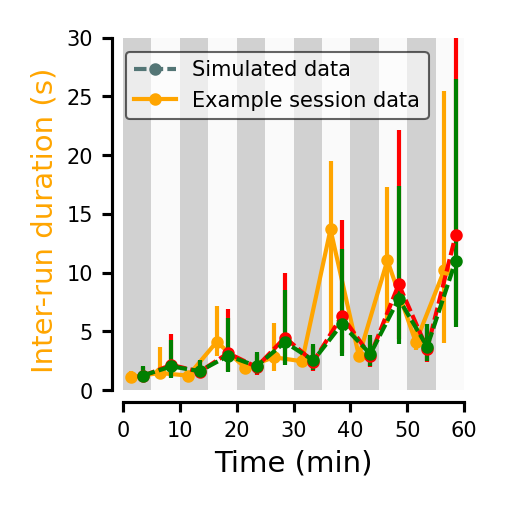

In [107]:
def Figure2E(root=root, ax=None, show_ylabel=False, animal=example_rat, session=example_session):
    if ax is None:
        ax = plt.gca()

    rewardProbaBlock = [90, 10, 90, 10, 90, 10, 90, 10, 90, 10, 90, 10]
    blocks =  [[0, 300],  [300, 600],  [600, 900],  [900, 1200],
                [1200, 1500],  [1500, 1800],  [1800, 2100],  [2100, 2400],
                [2400, 2700],  [2700, 3000],  [3000, 3300],  [3300, 3600]]
    
    for i in range(0, len(blocks)):
        ax.axvspan(blocks[i][0]/60, blocks[i][1]/60, ymin=1/30, ymax=1, color='grey', alpha=rewardProbaBlock[i]/250, lw=0)
    
    ax.set_xlabel("Time (min)")
    if show_ylabel:
        ax.set_ylabel("Inter-run duration (s)", color='orange')
    ax.set_xlim(0, 60)
    ax.set_xticks([0, 10, 20, 30, 40, 50, 60])
    ax.set_ylim(0, 30)
    # ax.set_yticks([0, 5, 10, 15])
    space_axes(ax)


    # experimental rat data
    _params = get_from_pickle(root, animal, session, name="params.p")
    blocks = _params['blocks']
    rewardProbaBlock = _params['rewardProbaBlock']
    example_runningTimeInLeftBin, example_runningTimeInRightBin = get_from_pickle(root, animal, session, name="timeinZone.p")
    data = [example_runningTimeInLeftBin[i]+example_runningTimeInRightBin[i] for i in range(0, 12)]

    data_medians = [np.median(data[i]) for i in range(12)]
    data_bot_percentiles = [np.percentile(data[i], 25) for i in range(12)]
    data_top_percentiles = [np.percentile(data[i], 75) for i in range(12)]
        
    ax.errorbar([-1+(blocks[i][1] + blocks[i][0])/120 for i in range(0, len(blocks))],
                data_medians,
                yerr=[[data_medians[i]-data_bot_percentiles[i] for i in range(12)], [data_top_percentiles[i]-data_medians[i] for i in range(12)]],
                marker='o', ms=2, color='orange', 
                zorder=4, alpha=1)

    # fit, generate samples from distribution with fit parameters, take median
    N_bins = 6
    N_avg = 4
    ex_alpha, ex_alpha_t, ex_alpha_u, ex_gamma, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
    ALPHA = np.zeros((N_bins, N_avg))
    GAMMA = np.zeros((N_bins, N_avg))

    for bin in range(N_bins):
        for avg in range(N_avg):
            ALPHA[bin, avg] = ex_alpha + bin*ex_alpha_t + avg*ex_alpha_u
            GAMMA[bin, avg] = ex_gamma + bin*ex_gamma_t + avg*ex_gamma_u

    a = []
    g = []
    for i in range(6):
        a.append(.9*ALPHA[i][0]+0.1*ALPHA[i][1])
        a.append(.9*ALPHA[i][-1]+0.1*ALPHA[i][-2])
        g.append(.9*GAMMA[i][0]+0.1*GAMMA[i][1])
        g.append(.9*GAMMA[i][-1]+0.1*GAMMA[i][-2])
    print('previous')
    print(a)
    print(g)

    res = [generate_idle_time(a[i], g[i], 1000) for i in range(12)]
    medians = [np.median(res[i]) for i in range(12)]
    bot_percentiles = [np.percentile(res[i], 25) for i in range(12)]
    top_percentiles = [np.percentile(res[i], 75) for i in range(12)]

    ax.errorbar([1+(blocks[i][1] + blocks[i][0])/120 for i in range(0, len(blocks))],
                medians,
                yerr=[[medians[i]-bot_percentiles[i] for i in range(12)], [top_percentiles[i]-medians[i] for i in range(12)]],
                color='r', marker='o', ms=2, ls=(0, (3, 1)), zorder=5)
    




    ##############################################
    probs90 = correct_weights(0.9, 3)
    probs10 = correct_weights(0.1, 3)
    # print(probs90)
    # print(probs10)
    m = []
    s = []
    for i in range(6):
        m.append((probs90[3]*ALPHA[i][0] + probs90[2]*ALPHA[i][1] + probs90[1]*ALPHA[i][2] + probs90[0]*ALPHA[i][3]))
        m.append((probs10[3]*ALPHA[i][0] + probs10[2]*ALPHA[i][1] + probs10[1]*ALPHA[i][2] + probs10[0]*ALPHA[i][3]))
        s.append((probs90[3]*GAMMA[i][0] + probs90[2]*GAMMA[i][1] + probs90[1]*GAMMA[i][2] + probs90[0]*GAMMA[i][3]))
        s.append((probs10[3]*GAMMA[i][0] + probs10[2]*GAMMA[i][1] + probs10[1]*GAMMA[i][2] + probs10[0]*GAMMA[i][3]))

    print('now')
    print(m)
    print(s)
    res = [generate_idle_time(m[i], s[i], 1000) for i in range(12)]
    medians = [np.median(res[i]) for i in range(12)]
    bot_percentiles = [np.nanpercentile(res[i], 25) for i in range(12)]
    top_percentiles = [np.nanpercentile(res[i], 75) for i in range(12)]

    ax.errorbar([1+(blocks[i][1] + blocks[i][0])/120 for i in range(0, len(blocks))],
                medians,
                yerr=[[medians[i]-bot_percentiles[i] for i in range(12)], [top_percentiles[i]-medians[i] for i in range(12)]],
                color='g', marker='o', ms=2, ls=(0, (3, 1)), zorder=5)
    

    ################################################
    


    ax.plot([-100, -101], [-100, -101], color=rat_markers[example_rat][0], marker='o', ms=2, ls=(0, (3, 1)), label='Simulated data', zorder=5)
    ax.plot([-100, -101], [-100, -101], marker='o', ms=2, color='orange', zorder=4, alpha=1, label='Example session data')
   

    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique), loc='upper left', bbox_to_anchor=(0.01, 0.99), handlelength=2,
              frameon=True, fontsize=5, markerscale=1, edgecolor='k', 
              facecolor='w').get_frame().set_linewidth(.5)

fig, ax = plt.subplots(1, 1, figsize=(cm2inch(4), cm2inch(4)))

Figure2E(ax=ax, show_ylabel=True)